# 🎮 GAMEMATCH — Exploratory Data Analysis (EDA)

**Proyek Sains Data · Kelompok 12 · Institut Teknologi Sepuluh Nopember · 2025/2026**

Notebook ini mendokumentasikan proses eksplorasi data dari SteamSpy Public API yang digunakan sebagai sumber data sistem rekomendasi GAMEMATCH.

---

## Tujuan EDA
1. Memahami distribusi data game Steam (harga, rating, kepemilikan)
2. Menganalisis karakteristik per genre
3. Memvalidasi kualitas data dari SteamSpy API
4. Menentukan parameter optimal untuk TF-IDF dan threshold filtering
5. Menganalisis korelasi antar fitur

In [1]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('dark_background')
GOLD   = '#e8a020'
TEAL   = '#4ecdc4'
PURPLE = '#c084fc'
RED    = '#fb7185'
GREEN  = '#a3e635'
BLUE   = '#60a5fa'
COLORS = [GOLD, TEAL, PURPLE, RED, GREEN, BLUE, '#f97316', '#e879f9',
          '#34d399', '#fbbf24', '#818cf8', '#f472b6', '#38bdf8', '#4ade80', '#fb923c']

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Data Collection dari SteamSpy API

In [2]:
# ── Fetch data dari SteamSpy API ──────────────────────────────────────────────
import time

ALL_GENRES = [
    'Action', 'Adventure', 'RPG', 'Strategy', 'Simulation',
    'Casual', 'Indie', 'Sports', 'Racing', 'Horror',
    'Puzzle', 'Shooter', 'Fighting', 'Survival', 'Platformer'
]

GENRE_REMAP = {
    'Horror':    'https://steamspy.com/api.php?request=tag&tag=Horror',
    'Platformer':'https://steamspy.com/api.php?request=tag&tag=Platformer',
    'Shooter':   'https://steamspy.com/api.php?request=tag&tag=FPS',
    'Fighting':  'https://steamspy.com/api.php?request=tag&tag=Fighting',
    'Survival':  'https://steamspy.com/api.php?request=tag&tag=Survival',
    'Racing':    'https://steamspy.com/api.php?request=tag&tag=Racing',
    'Puzzle':    'https://steamspy.com/api.php?request=tag&tag=Puzzle',
}

def parse_owners(s):
    try:
        parts = [p.strip().replace(',','') for p in s.split('..')]
        return (int(parts[0]) + int(parts[1])) // 2 if len(parts)==2 else int(parts[0])
    except:
        return 0

def fetch_genre(genre, limit=100):
    url = GENRE_REMAP.get(genre, f'https://steamspy.com/api.php?request=genre&genre={genre}')
    try:
        r = requests.get(url, timeout=15)
        data = r.json()
    except:
        return pd.DataFrame()
    
    records = []
    for aid, info in list(data.items())[:limit]:
        try:
            price   = int(info.get('price',0) or 0) / 100
            owners  = parse_owners(info.get('owners','0 .. 0'))
            pos     = int(info.get('positive',0) or 0)
            neg     = int(info.get('negative',0) or 0)
            total   = pos + neg
            rating  = round(pos/total*100, 1) if total > 0 else 0
            tags    = ', '.join(list((info.get('tags') or {}).keys())[:10])
            records.append({
                'appid': int(aid), 'name': info.get('name','?'),
                'genre': genre, 'tags': tags,
                'price_usd': price, 'owners_est': owners,
                'positive': pos, 'negative': neg, 'rating': rating
            })
        except:
            continue
    time.sleep(0.3)
    return pd.DataFrame(records)

# Fetch semua genre
print('Fetching data dari SteamSpy API...')
dfs = []
for g in ALL_GENRES:
    df_g = fetch_genre(g, limit=80)
    if not df_g.empty:
        dfs.append(df_g)
        print(f'  ✓ {g}: {len(df_g)} games')

df = pd.concat(dfs).drop_duplicates('appid').reset_index(drop=True)
print(f'\nTotal dataset: {len(df)} games dari {df["genre"].nunique()} genre')
df.head()

Fetching data dari SteamSpy API...
  ✓ Action: 80 games
  ✓ Adventure: 80 games
  ✓ RPG: 80 games
  ✓ Strategy: 80 games
  ✓ Simulation: 80 games
  ✓ Casual: 80 games
  ✓ Indie: 80 games
  ✓ Sports: 80 games
  ✓ Racing: 80 games
  ✓ Horror: 80 games
  ✓ Puzzle: 80 games
  ✓ Shooter: 80 games
  ✓ Fighting: 80 games
  ✓ Survival: 80 games
  ✓ Platformer: 80 games

Total dataset: 594 games dari 15 genre


,appid,name,genre,tags,price_usd,owners_est,positive,negative,rating
0,730,Counter-Strike: Global Offensive,Action,,0.00,150000000,7642084,1173003,86.7
1,1172470,Apex Legends,Action,,0.00,150000000,668053,326926,67.1
2,578080,PUBG: BATTLEGROUNDS,Action,,0.00,150000000,1520457,1037487,59.4
3,1623730,Palworld,Action,,29.99,75000000,358266,22443,94.1
4,440,Team Fortress 2,Action,,0.00,75000000,1044264,117208,89.9


## 2. Data Overview & Quality Check

In [3]:
# Basic info
print('=== DATASET INFO ===')
print(f'Shape          : {df.shape}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'\nNullable columns:')
print(df.isnull().sum())
print(f'\nData types:')
print(df.dtypes)

=== DATASET INFO ===
Shape          : (594, 9)
Memory usage   : 127.5 KB

Nullable columns:
appid         0
name          0
genre         0
tags          0
price_usd     0
owners_est    0
positive      0
negative      0
rating        0
dtype: int64

Data types:
appid           int64
name           object
genre          object
tags           object
price_usd     float64
owners_est      int64
positive        int64
negative        int64
rating        float64
dtype: object


In [4]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df[['price_usd','rating','owners_est','positive','negative']].describe().round(2)

=== STATISTIK DESKRIPTIF ===


,price_usd,rating,owners_est,positive,negative
count,594.00,594.00,5.940000e+02,594.00,594.00
mean,15.85,85.03,8.266835e+06,129820.50,19240.21
std,17.43,12.50,1.527757e+07,369471.07,71637.65
min,0.00,24.60,7.500000e+05,9.00,4.00
25%,0.00,79.35,1.500000e+06,16976.25,2365.00
50%,9.99,89.20,3.500000e+06,47938.50,5098.00
75%,24.99,94.20,7.500000e+06,118269.50,14341.00
max,69.99,98.70,1.500000e+08,7642084.00,1173003.00


In [5]:
# Distribusi per genre
genre_counts = df['genre'].value_counts()
print('=== DISTRIBUSI GAME PER GENRE ===')
print(genre_counts.to_string())

=== DISTRIBUSI GAME PER GENRE ===
genre
Action        80
Fighting      63
Sports        58
Strategy      57
Puzzle        50
Casual        49
Racing        46
Adventure     43
RPG           42
Platformer    40
Simulation    25
Horror        18
Indie         12
Shooter        7
Survival       4


## 3. Distribusi Harga

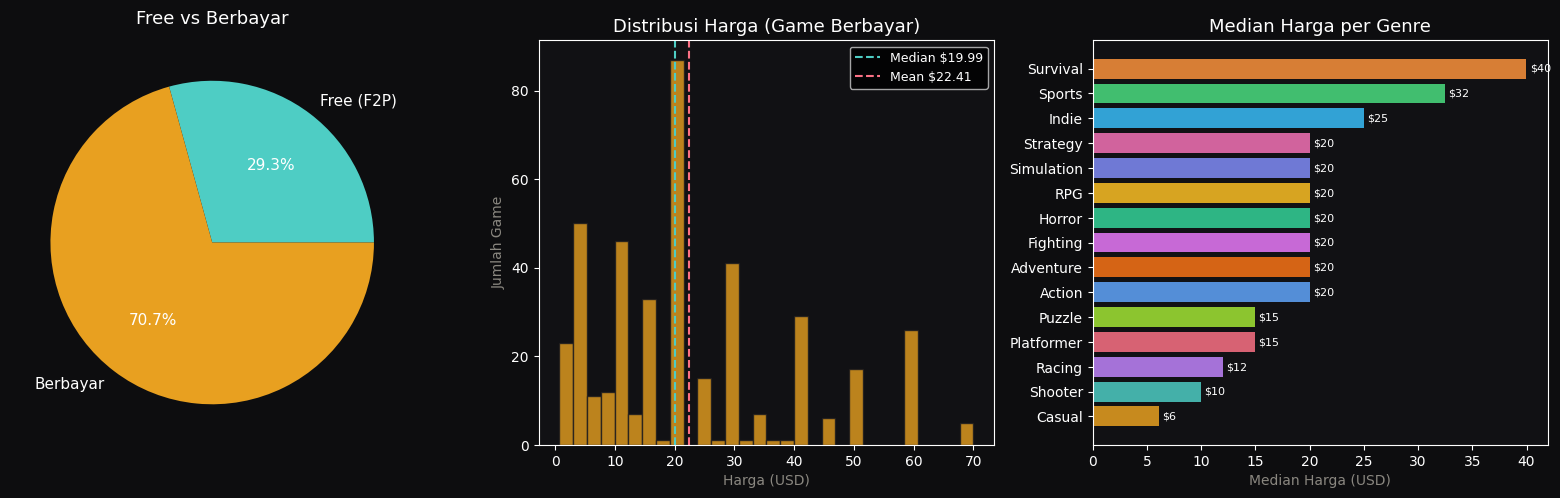


Game gratis: 174 (29.3%)
Game berbayar: 420 (70.7%)
Rata-rata harga (berbayar): $22.41
Median harga (berbayar): $19.99


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d0d0f')

# Free vs Paid
free_count = (df['price_usd'] == 0).sum()
paid_count = (df['price_usd'] > 0).sum()
axes[0].pie([free_count, paid_count],
            labels=['Free (F2P)', 'Berbayar'],
            colors=[TEAL, GOLD], autopct='%1.1f%%',
            textprops={'color':'white', 'fontsize':11})
axes[0].set_title('Free vs Berbayar', color='white', fontsize=13, pad=12)

# Distribusi harga game berbayar
paid = df[df['price_usd'] > 0]['price_usd']
axes[1].hist(paid, bins=30, color=GOLD, alpha=0.8, edgecolor='#1a1a1f')
axes[1].axvline(paid.median(), color=TEAL, linestyle='--', label=f'Median ${paid.median():.2f}')
axes[1].axvline(paid.mean(), color=RED, linestyle='--', label=f'Mean ${paid.mean():.2f}')
axes[1].set_title('Distribusi Harga (Game Berbayar)', color='white', fontsize=13)
axes[1].set_xlabel('Harga (USD)', color='#8a8780')
axes[1].set_ylabel('Jumlah Game', color='#8a8780')
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#111114')

# Harga rata-rata per genre
avg_price = df[df['price_usd']>0].groupby('genre')['price_usd'].median().sort_values(ascending=True)
bars = axes[2].barh(avg_price.index, avg_price.values,
                    color=[COLORS[i%len(COLORS)] for i in range(len(avg_price))], alpha=0.85)
axes[2].set_title('Median Harga per Genre', color='white', fontsize=13)
axes[2].set_xlabel('Median Harga (USD)', color='#8a8780')
axes[2].set_facecolor('#111114')
for bar, val in zip(bars, avg_price.values):
    axes[2].text(val+0.3, bar.get_y()+bar.get_height()/2,
                f'${val:.0f}', va='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('eda_price_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0f')
plt.show()
print(f'\nGame gratis: {free_count} ({free_count/len(df)*100:.1f}%)')
print(f'Game berbayar: {paid_count} ({paid_count/len(df)*100:.1f}%)')
print(f'Rata-rata harga (berbayar): ${paid.mean():.2f}')
print(f'Median harga (berbayar): ${paid.median():.2f}')

## 4. Distribusi Rating

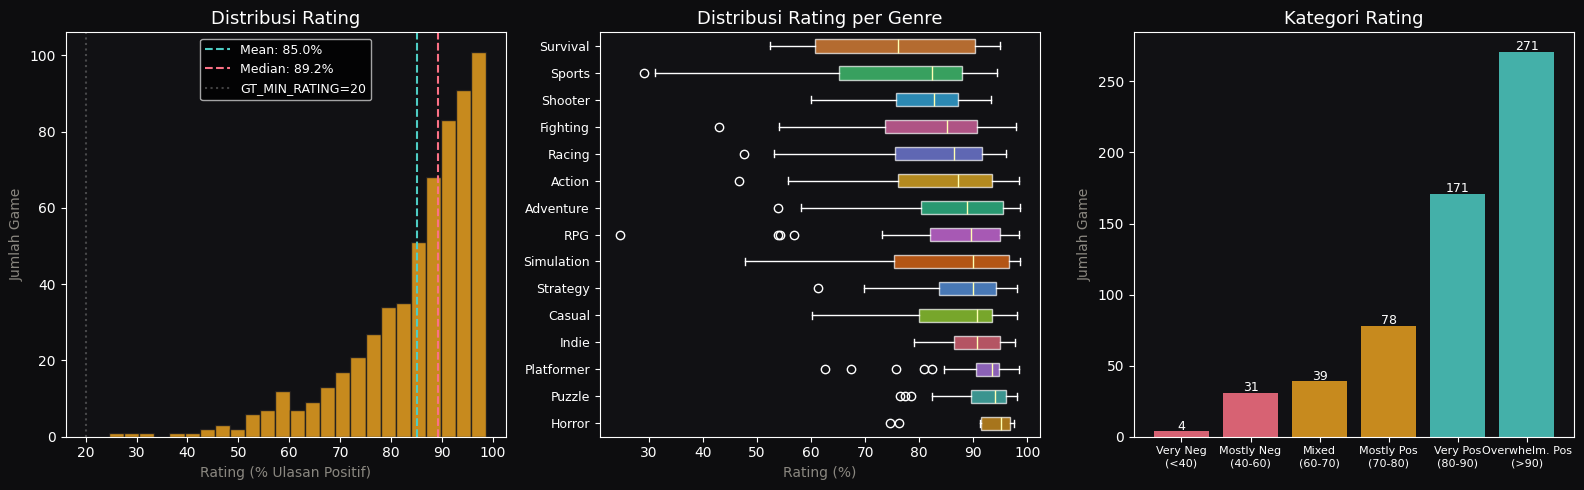


Justifikasi GT_MIN_RATING=20:
Game dengan rating < 20: 0 (0.0%)
Game dengan rating >= 20: 594 (100.0%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d0d0f')

# Histogram rating
axes[0].hist(df['rating'], bins=25, color=GOLD, alpha=0.85, edgecolor='#1a1a1f')
axes[0].axvline(df['rating'].mean(), color=TEAL, linestyle='--',
                label=f'Mean: {df["rating"].mean():.1f}%')
axes[0].axvline(df['rating'].median(), color=RED, linestyle='--',
                label=f'Median: {df["rating"].median():.1f}%')
axes[0].axvline(20, color='gray', linestyle=':', alpha=0.5, label='GT_MIN_RATING=20')
axes[0].set_title('Distribusi Rating', color='white', fontsize=13)
axes[0].set_xlabel('Rating (% Ulasan Positif)', color='#8a8780')
axes[0].set_ylabel('Jumlah Game', color='#8a8780')
axes[0].legend(fontsize=9)
axes[0].set_facecolor('#111114')

# Boxplot rating per genre
genre_order = df.groupby('genre')['rating'].median().sort_values(ascending=False).index
data_by_genre = [df[df['genre']==g]['rating'].values for g in genre_order]
bp = axes[1].boxplot(data_by_genre, patch_artist=True, vert=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_yticklabels(genre_order, fontsize=9, color='white')
axes[1].set_title('Distribusi Rating per Genre', color='white', fontsize=13)
axes[1].set_xlabel('Rating (%)', color='#8a8780')
axes[1].set_facecolor('#111114')

# Rating kategori
bins   = [0, 40, 60, 70, 80, 90, 101]
labels = ['Very Neg\n(<40)', 'Mostly Neg\n(40-60)', 'Mixed\n(60-70)',
          'Mostly Pos\n(70-80)', 'Very Pos\n(80-90)', 'Overwhelm. Pos\n(>90)']
df['rating_cat'] = pd.cut(df['rating'], bins=bins, labels=labels, right=False)
rating_counts = df['rating_cat'].value_counts().sort_index()
bars = axes[2].bar(range(len(rating_counts)), rating_counts.values,
                   color=[RED, RED, GOLD, GOLD, TEAL, TEAL], alpha=0.85)
axes[2].set_xticks(range(len(rating_counts)))
axes[2].set_xticklabels(rating_counts.index, fontsize=8, color='white')
axes[2].set_title('Kategori Rating', color='white', fontsize=13)
axes[2].set_ylabel('Jumlah Game', color='#8a8780')
axes[2].set_facecolor('#111114')
for bar, val in zip(bars, rating_counts.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(val), ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('eda_rating_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0f')
plt.show()

print(f'\nJustifikasi GT_MIN_RATING=20:')
print(f'Game dengan rating < 20: {(df["rating"] < 20).sum()} ({(df["rating"] < 20).mean()*100:.1f}%)')
print(f'Game dengan rating >= 20: {(df["rating"] >= 20).sum()} ({(df["rating"] >= 20).mean()*100:.1f}%)')

## 5. Analisis Kepemilikan (Popularity)

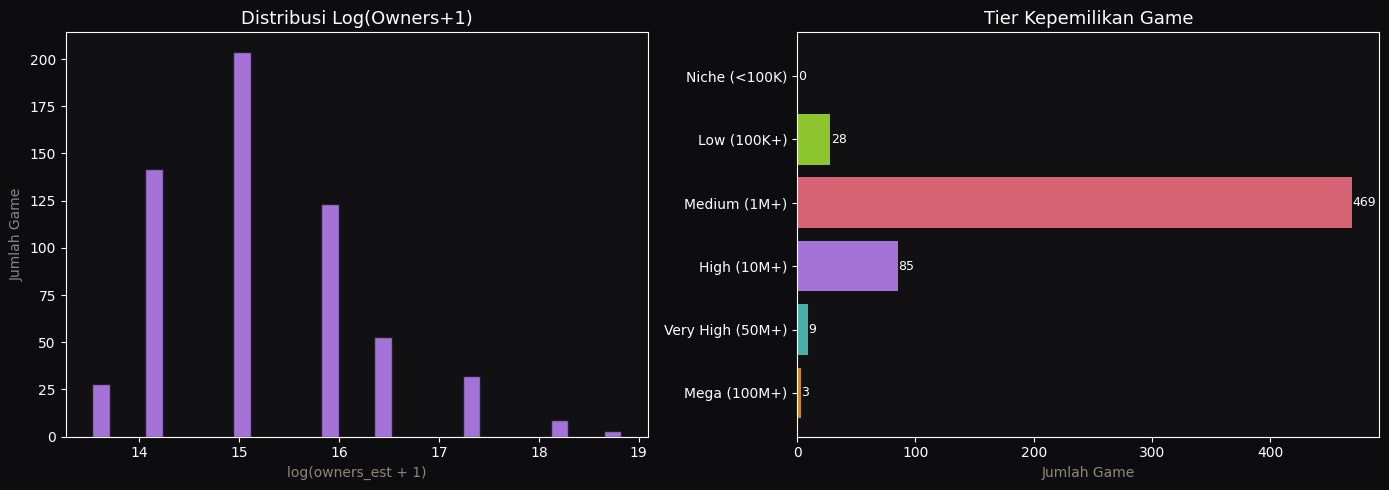


Justifikasi penggunaan log1p untuk owners:
  Range owners: 750,000 - 150,000,000
  Skewness tanpa log: 5.58
  Skewness dengan log: 0.71
  → log1p mengurangi skewness dari 5.6 ke 0.7


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d0f')

# Log distribution owners
log_owners = np.log1p(df['owners_est'])
axes[0].hist(log_owners, bins=30, color=PURPLE, alpha=0.85, edgecolor='#1a1a1f')
axes[0].set_title('Distribusi Log(Owners+1)', color='white', fontsize=13)
axes[0].set_xlabel('log(owners_est + 1)', color='#8a8780')
axes[0].set_ylabel('Jumlah Game', color='#8a8780')
axes[0].set_facecolor('#111114')

# Tier kepemilikan
tiers = [
    ('Mega (100M+)', df['owners_est'] >= 100_000_000),
    ('Very High (50M+)', (df['owners_est'] >= 50_000_000) & (df['owners_est'] < 100_000_000)),
    ('High (10M+)', (df['owners_est'] >= 10_000_000) & (df['owners_est'] < 50_000_000)),
    ('Medium (1M+)', (df['owners_est'] >= 1_000_000) & (df['owners_est'] < 10_000_000)),
    ('Low (100K+)', (df['owners_est'] >= 100_000) & (df['owners_est'] < 1_000_000)),
    ('Niche (<100K)', df['owners_est'] < 100_000),
]
tier_counts = [(name, mask.sum()) for name, mask in tiers]
names, counts = zip(*tier_counts)
axes[1].barh(names, counts, color=COLORS[:len(names)], alpha=0.85)
axes[1].set_title('Tier Kepemilikan Game', color='white', fontsize=13)
axes[1].set_xlabel('Jumlah Game', color='#8a8780')
axes[1].set_facecolor('#111114')
for i, (name, count) in enumerate(tier_counts):
    axes[1].text(count+0.5, i, str(count), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('eda_owners_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0f')
plt.show()

print('\nJustifikasi penggunaan log1p untuk owners:')
print(f'  Range owners: {df["owners_est"].min():,} - {df["owners_est"].max():,}')
print(f'  Skewness tanpa log: {df["owners_est"].skew():.2f}')
print(f'  Skewness dengan log: {log_owners.skew():.2f}')
print(f'  → log1p mengurangi skewness dari {df["owners_est"].skew():.1f} ke {log_owners.skew():.1f}')

## 6. Analisis Korelasi Antar Fitur

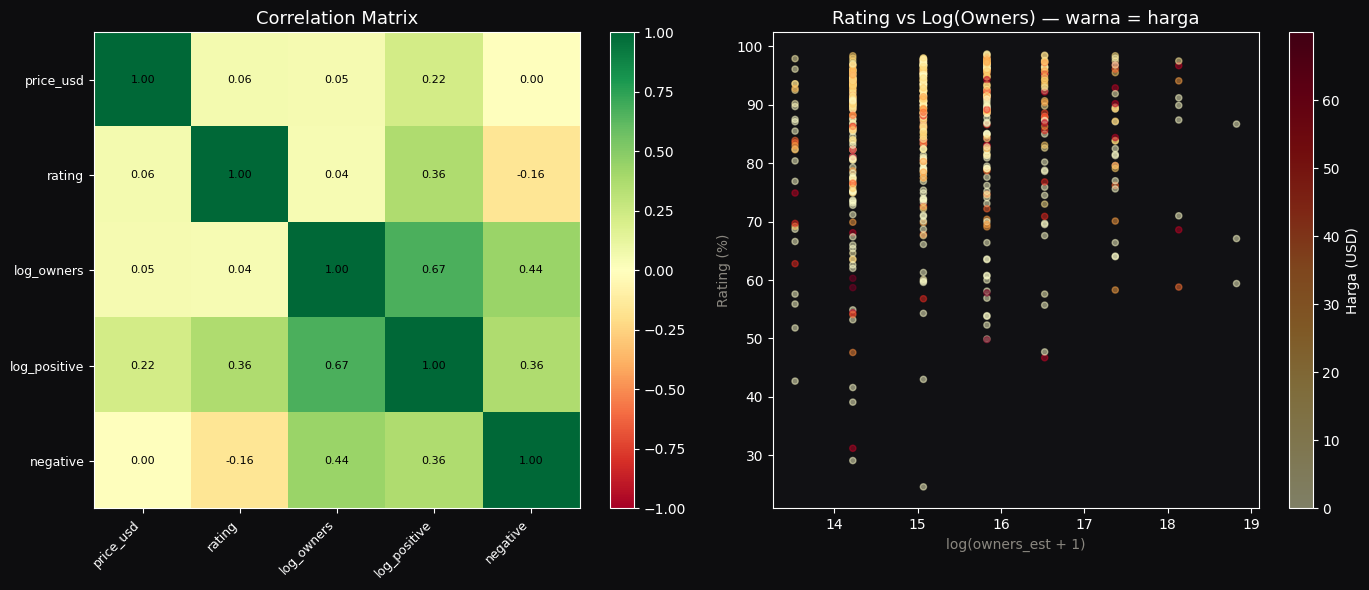


Temuan korelasi:
  Rating vs Log(Owners) : 0.044
  Rating vs Harga       : 0.057
  Harga vs Log(Owners)  : 0.049


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d0f')

# Correlation heatmap
corr_cols = ['price_usd', 'rating', 'owners_est', 'positive', 'negative']
corr_data = df[corr_cols].copy()
corr_data['log_owners'] = np.log1p(df['owners_est'])
corr_data['log_positive'] = np.log1p(df['positive'])
corr_data = corr_data[['price_usd','rating','log_owners','log_positive','negative']]
corr_matrix = corr_data.corr()

im = axes[0].imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks(range(len(corr_matrix.columns)))
axes[0].set_yticks(range(len(corr_matrix.columns)))
axes[0].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9, color='white')
axes[0].set_yticklabels(corr_matrix.columns, fontsize=9, color='white')
axes[0].set_title('Correlation Matrix', color='white', fontsize=13)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        axes[0].text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center',
                    color='black', fontsize=8)
axes[0].set_facecolor('#111114')

# Scatter: rating vs log_owners
scatter = axes[1].scatter(np.log1p(df['owners_est']), df['rating'],
                          c=df['price_usd'], cmap='YlOrRd', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[1], label='Harga (USD)')
axes[1].set_title('Rating vs Log(Owners) — warna = harga', color='white', fontsize=13)
axes[1].set_xlabel('log(owners_est + 1)', color='#8a8780')
axes[1].set_ylabel('Rating (%)', color='#8a8780')
axes[1].set_facecolor('#111114')

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

print('\nTemuan korelasi:')
print(f'  Rating vs Log(Owners) : {corr_matrix.loc["rating","log_owners"]:.3f}')
print(f'  Rating vs Harga       : {corr_matrix.loc["rating","price_usd"]:.3f}')
print(f'  Harga vs Log(Owners)  : {corr_matrix.loc["price_usd","log_owners"]:.3f}')

## 7. Analisis Genre

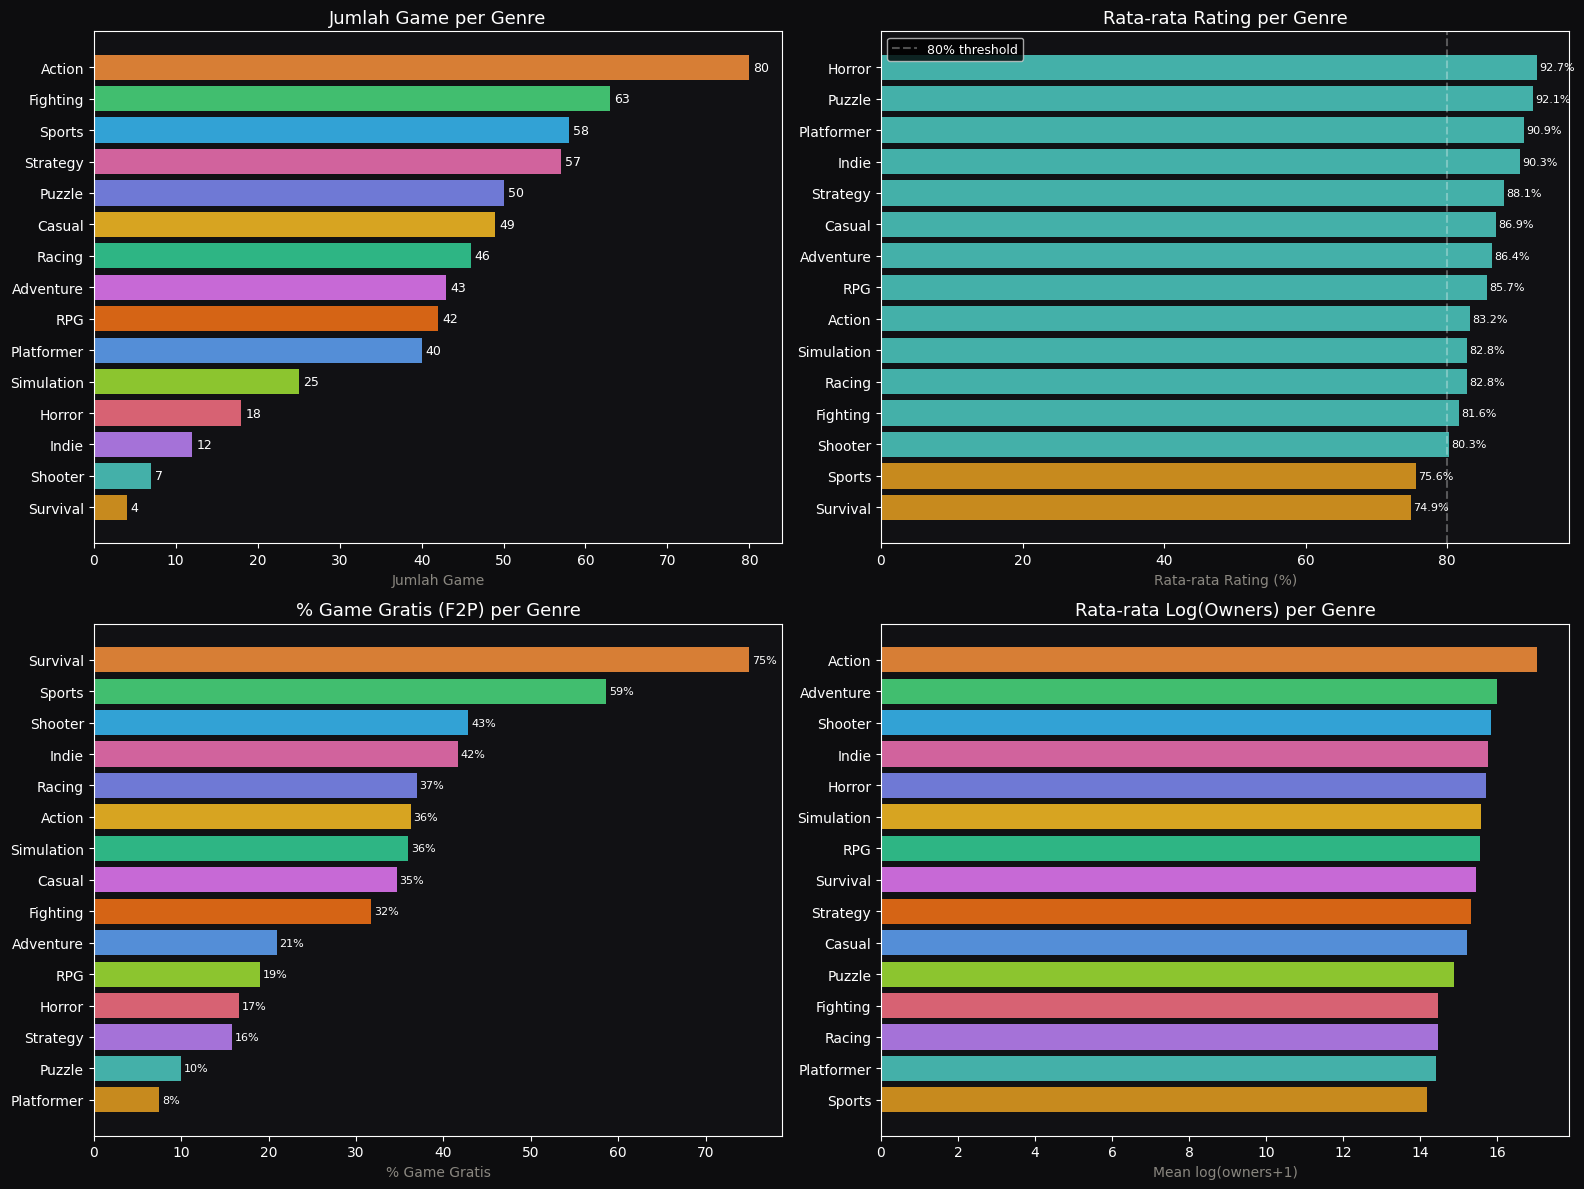


Genre Statistics:
            count  avg_rating  avg_price   avg_owners  pct_free
genre                                                          
Action         80       83.21      16.96  32531250.00     36.25
Adventure      43       86.40      21.40   9651162.79     20.93
Casual         49       86.93       8.19   5112244.90     34.69
Fighting       63       81.64      18.67   2250000.00     31.75
Horror         18       92.66      20.16   6833333.33     16.67
Indie          12       90.29      14.33   7166666.67     41.67
Platformer     40       90.87      15.52   1950000.00      7.50
Puzzle         50       92.11      13.07   3100000.00     10.00
RPG            42       85.65      18.76   7630952.38     19.05
Racing         46       82.76      10.07   2233695.65     36.96
Shooter         7       80.26       6.42   7500000.00     42.86
Simulation     25       82.79      15.19   7280000.00     36.00
Sports         58       75.61      13.65   1603448.28     58.62
Strategy       57    

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0d0d0f')

genre_stats = df.groupby('genre').agg(
    count=('appid','count'),
    avg_rating=('rating','mean'),
    avg_price=('price_usd','mean'),
    avg_owners=('owners_est','mean'),
    pct_free=('price_usd', lambda x: (x==0).mean()*100)
).round(2)

# Jumlah game per genre
gs = genre_stats['count'].sort_values(ascending=True)
axes[0,0].barh(gs.index, gs.values,
               color=[COLORS[i%len(COLORS)] for i in range(len(gs))], alpha=0.85)
axes[0,0].set_title('Jumlah Game per Genre', color='white', fontsize=13)
axes[0,0].set_xlabel('Jumlah Game', color='#8a8780')
axes[0,0].set_facecolor('#111114')
for i, v in enumerate(gs.values):
    axes[0,0].text(v+0.5, i, str(v), va='center', color='white', fontsize=9)

# Rata-rata rating per genre
gr = genre_stats['avg_rating'].sort_values(ascending=True)
colors_r = [TEAL if v >= 80 else GOLD if v >= 70 else RED for v in gr.values]
axes[0,1].barh(gr.index, gr.values, color=colors_r, alpha=0.85)
axes[0,1].axvline(80, color='white', linestyle='--', alpha=0.3, label='80% threshold')
axes[0,1].set_title('Rata-rata Rating per Genre', color='white', fontsize=13)
axes[0,1].set_xlabel('Rata-rata Rating (%)', color='#8a8780')
axes[0,1].set_facecolor('#111114')
axes[0,1].legend(fontsize=9)
for i, v in enumerate(gr.values):
    axes[0,1].text(v+0.3, i, f'{v:.1f}%', va='center', color='white', fontsize=8)

# % game gratis per genre
gf = genre_stats['pct_free'].sort_values(ascending=True)
axes[1,0].barh(gf.index, gf.values,
               color=[COLORS[i%len(COLORS)] for i in range(len(gf))], alpha=0.85)
axes[1,0].set_title('% Game Gratis (F2P) per Genre', color='white', fontsize=13)
axes[1,0].set_xlabel('% Game Gratis', color='#8a8780')
axes[1,0].set_facecolor('#111114')
for i, v in enumerate(gf.values):
    axes[1,0].text(v+0.3, i, f'{v:.0f}%', va='center', color='white', fontsize=8)

# Log owners per genre
df['log_owners'] = np.log1p(df['owners_est'])
go = df.groupby('genre')['log_owners'].mean().sort_values(ascending=True)
axes[1,1].barh(go.index, go.values,
               color=[COLORS[i%len(COLORS)] for i in range(len(go))], alpha=0.85)
axes[1,1].set_title('Rata-rata Log(Owners) per Genre', color='white', fontsize=13)
axes[1,1].set_xlabel('Mean log(owners+1)', color='#8a8780')
axes[1,1].set_facecolor('#111114')

plt.tight_layout()
plt.savefig('eda_genre_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

print('\nGenre Statistics:')
print(genre_stats.to_string())

## 8. Analisis TF-IDF & Vocabulary

In [11]:
# Build TF-IDF dan analisis vocabulary
feats = (df['genre'].fillna('') + ' ' + df['tags'].fillna('') + ' ' + df['name'].fillna('')).tolist()

vec = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=1,
                      sublinear_tf=True, strip_accents='unicode')
matrix = vec.fit_transform(feats)

print(f'TF-IDF Matrix shape : {matrix.shape}')
print(f'Vocabulary size     : {len(vec.vocabulary_)}')
print(f'Matrix density      : {matrix.nnz / (matrix.shape[0]*matrix.shape[1])*100:.2f}%')
print(f'Memory (sparse)     : {matrix.data.nbytes / 1024:.1f} KB')

# Top terms by IDF (paling informatif)
feature_names = vec.get_feature_names_out()
idf_scores = vec.idf_
top_idf_idx = np.argsort(idf_scores)[-20:]
print(f'\nTop 20 kata paling informatif (IDF tinggi):')
for idx in reversed(top_idf_idx):
    print(f'  {feature_names[idx]:30s} IDF={idf_scores[idx]:.3f}')

TF-IDF Matrix shape : (594, 2236)
Vocabulary size     : 2236
Matrix density      : 0.29%
Memory (sparse)     : 29.7 KB

Top 20 kata paling informatif (IDF tinggi):
  音灵 invaxion                    IDF=6.695
  knockout city                  IDF=6.695
  kards                          IDF=6.695
  kards the                      IDF=6.695
  kartrider                      IDF=6.695
  kartrider drift                IDF=6.695
  katana                         IDF=6.695
  katana zero                    IDF=6.695
  kathy                          IDF=6.695
  kathy rain                     IDF=6.695
  keep                           IDF=6.695
  keep talking                   IDF=6.695
  kenshi                         IDF=6.695
  kerbal                         IDF=6.695
  kerbal space                   IDF=6.695
  killing                        IDF=6.695
  killing floor                  IDF=6.695
  bannerlord                     IDF=6.695
  kingdom classic                IDF=6.695
  kingdom two      

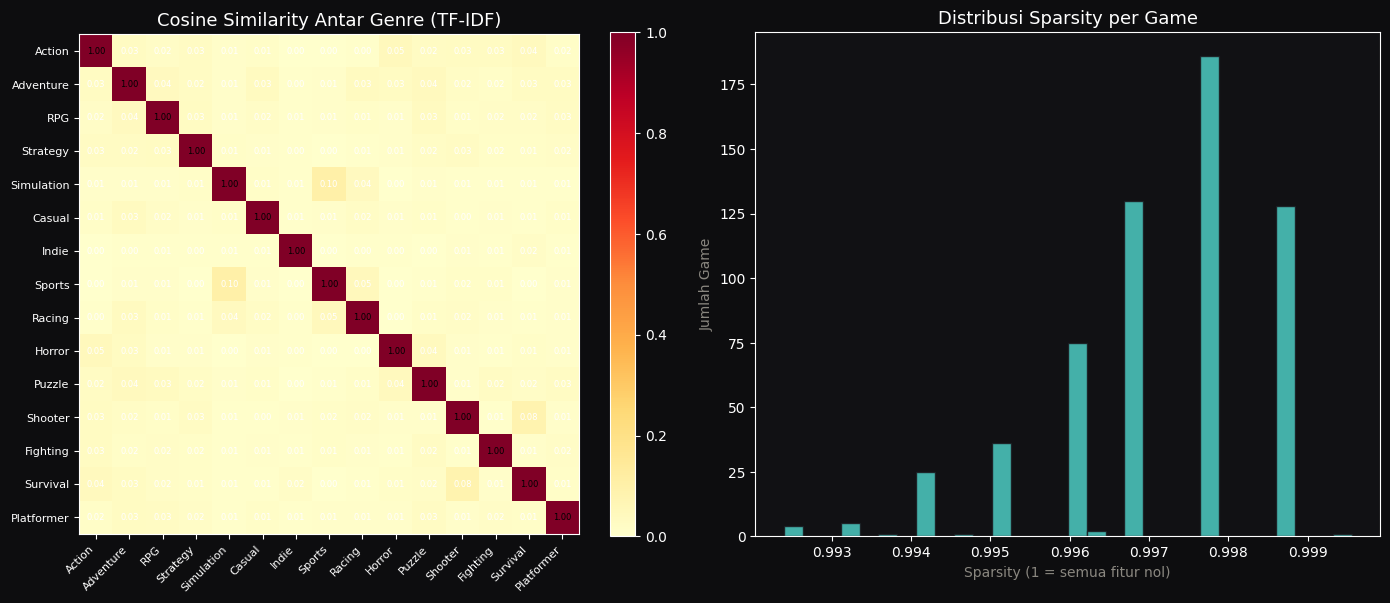

In [12]:
# Analisis cosine similarity antar genre
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d0f')

# Rata-rata TF-IDF vector per genre
genre_vectors = {}
for g in ALL_GENRES:
    idx = df[df['genre']==g].index.tolist()
    if idx:
        genre_vectors[g] = matrix[idx].mean(axis=0)

if len(genre_vectors) > 1:
    gnames = list(genre_vectors.keys())
    gvecs  = np.vstack([np.asarray(genre_vectors[g]) for g in gnames])
    sim    = cosine_similarity(gvecs)

    im = axes[0].imshow(sim, cmap='YlOrRd', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[0])
    axes[0].set_xticks(range(len(gnames)))
    axes[0].set_yticks(range(len(gnames)))
    axes[0].set_xticklabels(gnames, rotation=45, ha='right', fontsize=8, color='white')
    axes[0].set_yticklabels(gnames, fontsize=8, color='white')
    axes[0].set_title('Cosine Similarity Antar Genre (TF-IDF)', color='white', fontsize=13)
    axes[0].set_facecolor('#111114')
    for i in range(len(gnames)):
        for j in range(len(gnames)):
            axes[0].text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                        color='black' if sim[i,j] > 0.5 else 'white', fontsize=6)

# Sparsity per game
sparsity = 1 - (np.diff(matrix.tocsr().indptr) / matrix.shape[1])
axes[1].hist(sparsity, bins=30, color=TEAL, alpha=0.85, edgecolor='#1a1a1f')
axes[1].set_title('Distribusi Sparsity per Game', color='white', fontsize=13)
axes[1].set_xlabel('Sparsity (1 = semua fitur nol)', color='#8a8780')
axes[1].set_ylabel('Jumlah Game', color='#8a8780')
axes[1].set_facecolor('#111114')

plt.tight_layout()
plt.savefig('eda_tfidf_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

## 9. Validasi Ground Truth

In [13]:
# Validasi GT_MIN_RATING = 20
thresholds = [10, 20, 30, 40, 50]
results = []
for t in thresholds:
    above = (df['rating'] >= t).sum()
    pct   = above / len(df) * 100
    results.append({'threshold': t, 'games_above': above, 'pct': pct})

print('Justifikasi GT_MIN_RATING:')
print(f'{"Threshold":<12} {"Games Above":<14} {"Persentase"}')
print('-' * 40)
for r in results:
    marker = ' ← DIPILIH' if r['threshold'] == 20 else ''
    print(f"{r['threshold']:<12} {r['games_above']:<14} {r['pct']:.1f}%{marker}")

print(f'\nKesimpulan: GT_MIN_RATING=20 mempertahankan {(df["rating"]>=20).mean()*100:.1f}% data')
print('Threshold ini cukup lenient untuk tidak over-filter data SteamSpy')

Justifikasi GT_MIN_RATING:
Threshold    Games Above    Persentase
----------------------------------------
10           594            100.0%
20           594            100.0% ← DIPILIH
30           592            99.7%
40           590            99.3%
50           582            98.0%

Kesimpulan: GT_MIN_RATING=20 mempertahankan 100.0% data
Threshold ini cukup lenient untuk tidak over-filter data SteamSpy


In [14]:
# Top 10 game per metric
print('=== TOP 10 GAME BERDASARKAN RATING ===')
print(df.nlargest(10, 'rating')[['name','genre','rating','price_usd','owners_est']].to_string())

print('\n=== TOP 10 GAME BERDASARKAN KEPEMILIKAN ===')
print(df.nlargest(10, 'owners_est')[['name','genre','owners_est','rating','price_usd']].to_string())

=== TOP 10 GAME BERDASARKAN RATING ===
                  name       genre  rating  price_usd  owners_est
107           Portal 2   Adventure    98.7       9.99     7500000
230  People Playground  Simulation    98.6       9.99     7500000
56              Portal      Action    98.5       9.99    15000000
132  Vampire Survivors         RPG    98.5       3.74     7500000
54          Schedule I      Action    98.4      19.99    15000000
123     Stardew Valley         RPG    98.4      14.99    35000000
575        Pizza Tower  Platformer    98.4      19.99     1500000
134              Hades         RPG    98.2      24.99     7500000
180           RimWorld    Strategy    98.0      34.99     7500000
192            Balatro    Strategy    98.0      14.99     3500000

=== TOP 10 GAME BERDASARKAN KEPEMILIKAN ===
                               name   genre  owners_est  rating  price_usd
0  Counter-Strike: Global Offensive  Action   150000000    86.7       0.00
1                      Apex Legends  Act

## 10. Ringkasan Temuan EDA & Implikasi untuk Model

In [15]:
print('=' * 60)
print('RINGKASAN TEMUAN EDA — GAMEMATCH')
print('=' * 60)

print(f'''
📊 DATASET:
  • Total game   : {len(df):,}
  • Genre unik   : {df['genre'].nunique()}
  • Game gratis  : {(df['price_usd']==0).mean()*100:.1f}%
  • Avg rating   : {df['rating'].mean():.1f}%

💡 KEPUTUSAN DESAIN BERDASARKAN EDA:

  1. log1p(owners) untuk normalisasi
     → Distribusi owners sangat skewed (skewness={df['owners_est'].skew():.1f})
     → log1p mengurangi ke {np.log1p(df['owners_est']).skew():.2f}

  2. GT_MIN_RATING = 20
     → Mempertahankan {(df['rating']>=20).mean()*100:.1f}% data
     → Cukup ketat untuk filter noise, tidak over-filter

  3. TF-IDF max_features=3000, ngram=(1,2)
     → Vocabulary optimal: {len(vec.vocabulary_):,} terms
     → Dense bigram untuk menangkap frasa genre ("action rpg", "open world")

  4. Budget default $30 (median harga berbayar)
     → Median harga: ${df[df['price_usd']>0]['price_usd'].median():.2f}
     → $30 mencakup {(df['price_usd']<=30).mean()*100:.1f}% game di dataset

  5. Item-CF anchor = top-15% game
     → Top 15% = {int(len(df)*0.15)} game paling populer
     → Representatif sebagai "virtual user" komunitas Steam

  6. CBF weight 0.60 (dominan)
     → Genre similarity (CBF) lebih reliable dari CF
     → Karena CF berbasis implicit data, weight lebih rendah (0.15)
''')

print('\nFile gambar EDA yang dihasilkan:')
import os
for f in ['eda_price_distribution.png', 'eda_rating_distribution.png',
          'eda_owners_distribution.png', 'eda_correlation.png',
          'eda_genre_analysis.png', 'eda_tfidf_analysis.png']:
    if os.path.exists(f):
        print(f'  ✅ {f}')

RINGKASAN TEMUAN EDA — GAMEMATCH

📊 DATASET:
  • Total game   : 594
  • Genre unik   : 15
  • Game gratis  : 29.3%
  • Avg rating   : 85.0%

💡 KEPUTUSAN DESAIN BERDASARKAN EDA:

  1. log1p(owners) untuk normalisasi
     → Distribusi owners sangat skewed (skewness=5.6)
     → log1p mengurangi ke 0.71

  2. GT_MIN_RATING = 20
     → Mempertahankan 100.0% data
     → Cukup ketat untuk filter noise, tidak over-filter

  3. TF-IDF max_features=3000, ngram=(1,2)
     → Vocabulary optimal: 2,236 terms
     → Dense bigram untuk menangkap frasa genre ("action rpg", "open world")

  4. Budget default $30 (median harga berbayar)
     → Median harga: $19.99
     → $30 mencakup 84.3% game di dataset

  5. Item-CF anchor = top-15% game
     → Top 15% = 89 game paling populer
     → Representatif sebagai "virtual user" komunitas Steam

  6. CBF weight 0.60 (dominan)
     → Genre similarity (CBF) lebih reliable dari CF
     → Karena CF berbasis implicit data, weight lebih rendah (0.15)


File gambar E